# Chapter 05 Exercise Questions
Topic covering the Pandas package

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

os.chdir(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))

### Question 1

a) Create a Series containing the boiling points of the above solvents with the solvent names as the indices. Call the Series to look up the boiling point of ethanol.

b) Create a DataFrame that contains both the boiling points and melting points with the solvent names as the indices. Call the DataFrame to look up the melting point of benzene.

c) Access the boiling point of pentane in the DataFrame from part b using numerical indices.

In [3]:
bp = pd.Series([80,56,111,46,35,78,65], index=['Benzene', 'Acetone', 'Toluene', 'Pentane', 'Ether', 'Ethanol', 'Methanol'])
bp['Ethanol']

np.int64(78)

In [4]:
name = ['Benzene', 'Acetone', 'Toluene', 'Pentane', 'Ether', 'Ethanol', 'Methanol']
bp = [80,56,111,46,35,78,65]
mp = [5, -95, -95, -130, -116, -114, -98]
df = pd.DataFrame([name, bp, mp],
                   columns=name , index=(['Name', 'Boiling Point', 'Melting Point']))
df

,Benzene,Acetone,Toluene,Pentane,Ether,Ethanol,Methanol
Name,Benzene,Acetone,Toluene,Pentane,Ether,Ethanol,Methanol
Boiling Point,80,56,111,46,35,78,65
Melting Point,5,-95,-95,-130,-116,-114,-98


In [5]:
df.iloc[1, 0]

80

### Question 2

Import the attached file blue1.csv containing the absorption spectrum of Blue 1 food dye using pandas.

a) Set the wavelengths as the index values.

b) Plot the absorption versus wavelength.

c) Determine the absorbance of Blue 1 at 620 nm.

In [6]:
blue1 = pd.read_csv('data/blue1.csv')
blue1.set_index('nm', inplace=True)

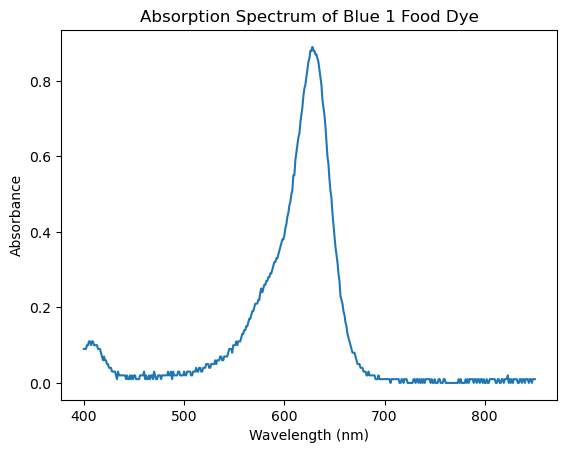

In [7]:
plt.plot(blue1.index, blue1['abs'])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorbance')
plt.title('Absorption Spectrum of Blue 1 Food Dye')
plt.show()

In [8]:
blue1.loc[620,'abs']

np.float64(0.78)

### Question 3
Chemical Kinetics: Import the file kinetics.csv containing time series data for the conversion of A -> Product using pandas IO tools. Generate new columns for $ln[A]$,$[A]^-1$ and $[A]^{0.5}$ and determine the order of the reaction.

In [9]:
kinetics = pd.read_csv('data/kinetics.csv', index_col=0)

In [10]:
kinetics['ln[A]'] = np.log(kinetics['[A](M)'])
kinetics['1/[A]'] = (kinetics['[A](M)']) ** -1
kinetics['[A]^0.5'] = (kinetics['[A](M)']) ** 0.5

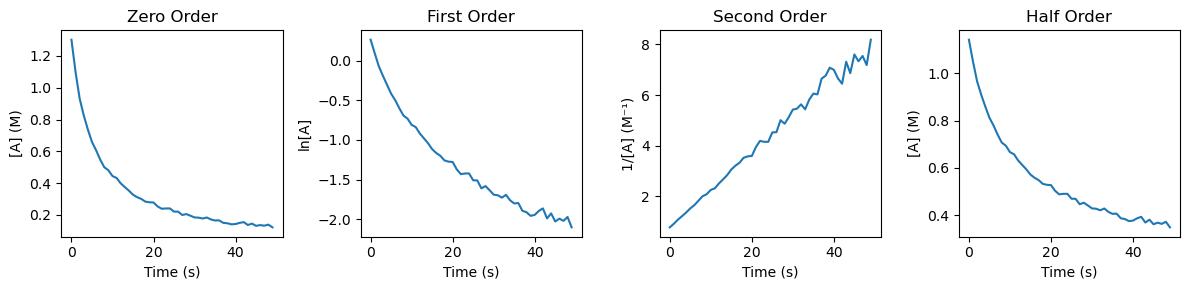

In [11]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 3))

ax1.plot(kinetics.index, kinetics['[A](M)'])
ax1.set_title('Zero Order')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('[A] (M)')

ax2.plot(kinetics.index, kinetics['ln[A]'])
ax2.set_title('First Order')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('ln[A]')

ax3.plot(kinetics.index, kinetics['1/[A]'])
ax3.set_title('Second Order')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('1/[A] (M⁻¹)')

ax4.plot(kinetics.index, kinetics['[A]^0.5'])
ax4.set_title('Half Order')
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('[A] (M)')

plt.tight_layout()
plt.show()

### The reaction is second order with respect to A.

### Question 4
Import the ROH_data.csv file containing data on various simple alcohols to a DataFrame. Notice that this data is missing densities for some of the compounds.

a) Use pandas to remove any rows with incomplete information in the density column using the `pd.dropna()` function. Check the DataFrame to see if it has changed.

b) Again using the `pd.dropna()` function, drop incomplete rows with the parameter `inplace=True`. Check to see if the DataFrame has changed.



In [12]:
ROH = pd.read_csv('data/ROH_data.csv')
ROH.dropna()

,bp,density,MW
0,64.7,0.792,32.04
1,78.4,0.789,46.07
2,97.5,0.803,60.10
3,82.6,0.786,60.10
4,117.7,0.810,74.12
5,99.0,0.808,74.12
6,107.9,0.802,74.12
7,82.5,0.775,74.12
8,138.5,0.811,88.15
9,131.2,0.810,88.15


In [13]:
ROH.tail(5)

,bp,density,MW
67,162.0,0.962,100.15
68,165.0,0.930,114.19
69,172.0,NaN,114.19
70,163.0,0.910,114.19
71,139.0,0.950,86.13


In [14]:
ROH.dropna(inplace=True)
ROH.tail()

,bp,density,MW
64,232.0,0.980,136.19
67,162.0,0.962,100.15
68,165.0,0.930,114.19
70,163.0,0.910,114.19
71,139.0,0.950,86.13


### Question 5
Import the following four files containing UV-vis spectra of four food dyes with the first column listing the wavelengths (nm) and the second column containing the absorbances. Each file contains data from 400-850 nm in 1 nm increments.

$$ red40.csv \space green3.csv \space blue1.csv \space yellow6.csv$$

a) Concatenate the files into a single DataFrame with the first column as the wavelength (nm) and the other four columns as the absorbances for each dye.

b) Replace the column headers with meaningful labels.

In [15]:
red = pd.read_csv('data/red40.csv', skiprows=(2))
green = pd.read_csv('data/green3.csv', skiprows=(2))
blue = pd.read_csv('data/blue1.csv')
yellow = pd.read_csv('data/yellow6.csv', skiprows=(2))

In [16]:
red = pd.read_csv('data/red40.csv', skiprows=3, names=['nm', 'Red 40'], index_col='nm')
green = pd.read_csv('data/green3.csv', skiprows=3, names=['nm', 'Green 3'], index_col='nm')
yellow = pd.read_csv('data/yellow6.csv', skiprows=3, names=['nm', 'Yellow 6'], index_col='nm')
blue = pd.read_csv('data/blue1.csv', names=['nm', 'Blue 1'], index_col='nm', header=0)

dyes = pd.concat([red, green, yellow, blue], axis=1)
#pd.concat() used due to blue1.csv having different nm layout to the other csv files
dyes

,Red 40,Green 3,Yellow 6,Blue 1
nm,,,,
200,0.09,0.00,0.02,NaN
201,0.09,-0.32,-0.15,NaN
202,0.37,0.41,0.24,NaN
203,1.44,-0.04,0.32,NaN
204,0.00,0.65,0.16,NaN
...,...,...,...,...
846,0.00,0.00,0.00,0.01
847,0.00,0.00,0.00,0.00
848,0.00,0.00,0.00,0.01


### Question 6
Import the two files `alcohols.csv` and `alkanes.csv` containing the boiling points of the two classes of organic compounds with respect to the number of carbons in each compound.

a) Drop the columns containing the names of the compounds.

b) Merge the two DataFrames allowing pandas to align the two DataFrames based on carbon number.

In [18]:
alcohols = pd.read_csv('data/alcohols.csv')
alkanes = pd.read_csv('data/alkanes.csv')

In [34]:
alcohols.drop('compound', axis=1).merge(
    alkanes.drop('compound', axis=1), on=('carbons')).sort_values('carbons')

,carbons,alcohol_bp,alkane_bp
8,1,64.7,-162.0
1,2,78.4,-89.0
2,3,97.5,-42.0
0,4,117.7,-1.0
4,5,138.5,36.0
7,6,157.0,69.0
9,7,175.8,98.0
3,8,195.0,126.0
13,9,212.0,151.0
12,10,232.0,174.0
